# Breast cancer diagnosis dataset exploration
## Exploration questions
#### Can tumor size help distinguish between benign and malignant tumors? 
#### Can the addition of other physical feature measurements help separate malignant tumors from benign tumors better? 

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import sklearn as sk


In [33]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = data.data
Y = data.target
dir(data)
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = Y
df["target"].value_counts()



target
1    357
0    212
Name: count, dtype: int64

The dataset contains more benign than malignant samples, which introduces a class imbalance that must be considered when evaluating model performance.

In [34]:
df.head()
df[df["target"] == 0]["mean radius"].describe()


count    212.000000
mean      17.462830
std        3.203971
min       10.950000
25%       15.075000
50%       17.325000
75%       19.590000
max       28.110000
Name: mean radius, dtype: float64

In [35]:
df[df["target"] == 1]["mean radius"].describe()


count    357.000000
mean      12.146524
std        1.780512
min        6.981000
25%       11.080000
50%       12.200000
75%       13.370000
max       17.850000
Name: mean radius, dtype: float64

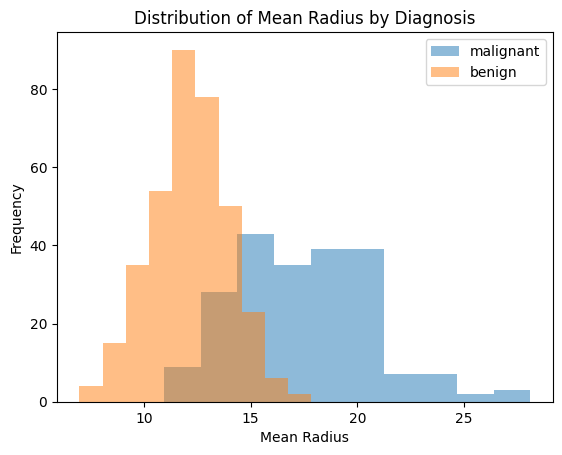

In [36]:
plt.hist(df[df["target"] == 0]["mean radius"], alpha=0.5, label="malignant")
plt.hist(df[df["target"] == 1]["mean radius"], alpha=0.5, label="benign")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Radius by Diagnosis")
plt.legend()
plt.show()

Malignant tumors have a higher average mean radius compared to benign tumors, suggesting that tumor size may be associated with malignancy. However, since the ranges overlap, tumor size alone cannot determine malignancy.

Can the addition of mean texture help separate benign and malignant tumors better?


In [38]:
df[df["target"] == 0]["mean texture"].describe()

count    212.000000
mean      21.604906
std        3.779470
min       10.380000
25%       19.327500
50%       21.460000
75%       23.765000
max       39.280000
Name: mean texture, dtype: float64

In [39]:
df[df["target"] == 1]["mean texture"].describe()

count    357.000000
mean      17.914762
std        3.995125
min        9.710000
25%       15.150000
50%       17.390000
75%       19.760000
max       33.810000
Name: mean texture, dtype: float64

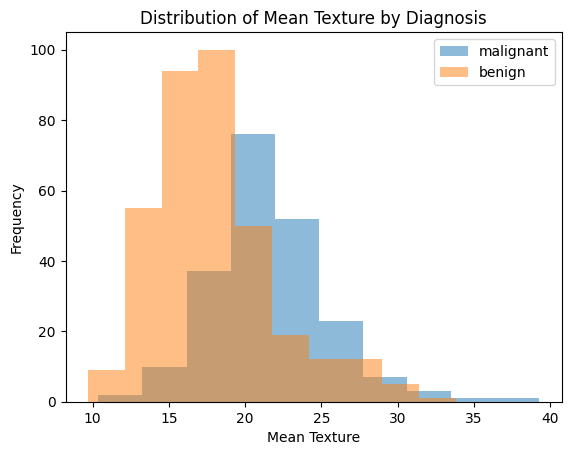

In [40]:
plt.hist(df[df["target"] == 0]["mean texture"], alpha=0.5, label="malignant")
plt.hist(df[df["target"] == 1]["mean texture"], alpha=0.5, label="benign")
plt.xlabel("Mean Texture")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Texture by Diagnosis")
plt.legend()
plt.show()

Malignant tumors have a higher average mean texture compared to benign tumors, suggesting that tumor texture may be associated with malignancy. However, since the ranges overlap, tumor texture alone cannot determine malignancy.

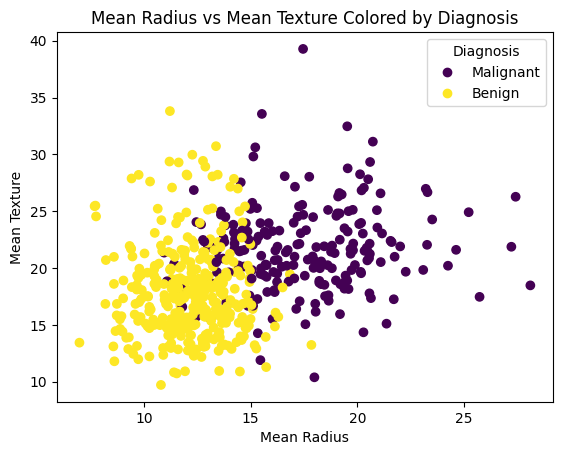

In [45]:
scatter = plt.scatter(df["mean radius"], df["mean texture"], c=df["target"])

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Mean Radius vs Mean Texture Colored by Diagnosis")

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=["Malignant", "Benign"],
    title="Diagnosis"
)

plt.show()

In [47]:
X_radius = df[["mean radius"]]
X_texture = df[["mean texture"]]
X_both = df[["mean radius", "mean texture"]]
y_malignant = 1 - df["target"]

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X_radius, y_malignant,
    test_size=0.2,
    random_state=42
)
model = LogisticRegression()
model.fit(X_train, y_train)
y_scores = model.predict_proba(X_test)[:, 1]

In [54]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_scores)

0.9695381591876843

#### AUC for Mean Radius

Using mean radius alone, the logistic regression model achieved an AUC of approximately 0.970. This suggests that mean radius provides strong separation between malignant and benign tumors, despite some overlap in the raw feature ranges.

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X_texture, y_malignant,
    test_size=0.2,
    random_state=42
)
model = LogisticRegression()
model.fit(X_train, y_train)
y_scores = model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_scores)

0.7615460203078939

#### AUC for Mean Texture

Using mean texture alone, the logistic regression model achieved an AUC of approximately 0.762. This suggests that mean texture has moderate ability to distinguish malignant from benign tumors, but it is less informative than mean radius.

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X_both, y_malignant,
    test_size=0.2,
    random_state=42
)
model = LogisticRegression()
model.fit(X_train, y_train)
y_scores = model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_scores)

0.973141172617098

#### Radius and Texture Together

This scatter plot compares mean radius and mean texture, with points colored by diagnosis. Malignant tumors generally appear more concentrated toward higher radius and texture values, while benign tumors are more common at lower radius values. However, there is still overlap between the two classes, suggesting that radius and texture together provide more information than either feature alone, but still do not perfectly separate malignant and benign tumors.

The logistic regression model using mean radius alone achieved an AUC of approximately 0.970, indicating strong separation between malignant and benign tumors. Mean texture alone achieved a lower AUC of approximately 0.762, suggesting moderate predictive value. Combining mean radius and mean texture slightly improved the AUC to approximately 0.973.

This suggests that mean radius is the stronger individual predictor, while mean texture adds a small amount of additional information when used alongside radius. Now, the question is whether the addition of another feature aka mean concavity will add to the precision of the model. 

In [58]:
df[df["target"] == 0]["mean concavity"].describe()

count    212.000000
mean       0.160775
std        0.075019
min        0.023980
25%        0.109525
50%        0.151350
75%        0.203050
max        0.426800
Name: mean concavity, dtype: float64

In [59]:
df[df["target"] == 1]["mean concavity"].describe()

count    357.000000
mean       0.046058
std        0.043442
min        0.000000
25%        0.020310
50%        0.037090
75%        0.059990
max        0.410800
Name: mean concavity, dtype: float64

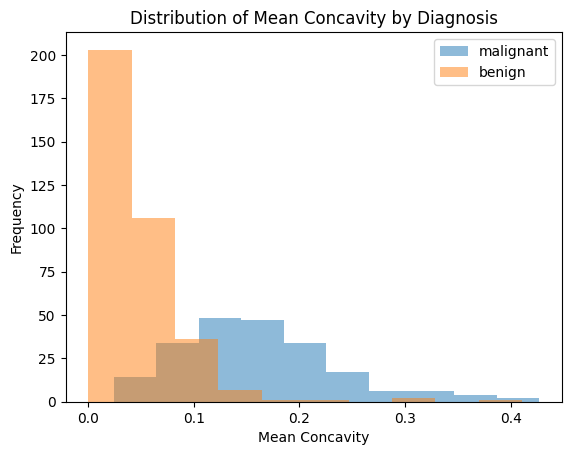

In [60]:
plt.hist(df[df["target"] == 0]["mean concavity"], alpha=0.5, label="malignant")
plt.hist(df[df["target"] == 1]["mean concavity"], alpha=0.5, label="benign")
plt.xlabel("Mean Concavity")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Concavity by Diagnosis")
plt.legend()
plt.show()

Malignant tumors have a higher average mean concavity compared to benign tumors, suggesting that tumor concavity may be associated with malignancy. However, since the ranges overlap, tumor concavity alone cannot determine malignancy.

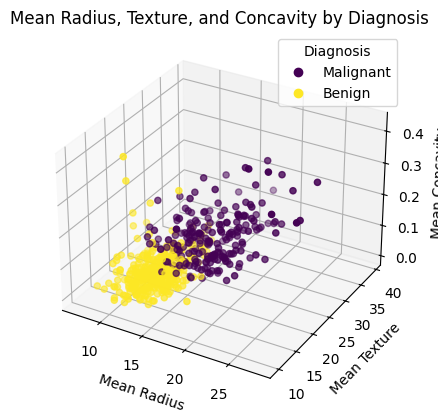

In [61]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["mean radius"],
    df["mean texture"],
    df["mean concavity"],
    c=df["target"]
)

ax.set_xlabel("Mean Radius")
ax.set_ylabel("Mean Texture")
ax.set_zlabel("Mean Concavity")
ax.set_title("Mean Radius, Texture, and Concavity by Diagnosis")

ax.legend(
    handles=scatter.legend_elements()[0],
    labels=["Malignant", "Benign"],
    title="Diagnosis"
)

plt.show()

In the 3D scatter plot, malignant and benign tumors appear more clearly separated when mean radius, mean texture, and mean concavity are viewed together. This suggests that combining size, texture, and shape-based features provides better visual separation than using radius and texture alone.

In [63]:
X_radius = df[["mean radius"]]
X_texture = df[["mean texture"]]
X_concavity = df[["mean concavity"]]
X_three = df[["mean radius", "mean texture", "mean concavity"]]
y_malignant = 1 - df["target"]

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X_concavity, y_malignant,
    test_size=0.2,
    random_state=42
)
model = LogisticRegression()
model.fit(X_train, y_train)
y_scores = model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_scores)

0.9610219456272519

#### AUC for Mean Concavity

Using mean concavity alone, the logistic regression model achieved an AUC of approximately 0.961. This suggests that mean concavity provides strong separation between malignant and benign tumors, despite some overlap in the raw feature ranges.It is a much stronger model than just mean texture but slightly weaker than just mean radius. 

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X_three, y_malignant,
    test_size=0.2,
    random_state=42
)
model = LogisticRegression()
model.fit(X_train, y_train)
y_scores = model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_scores)

0.9790370127743203

#### AUC for Radius, Texture, and Concavity

Using mean radius, mean texture, and mean concavity together, the logistic regression model achieved an AUC of approximately 0.979. This was the highest AUC among the tested feature combinations.

This suggests that combining size, texture, and shape-based measurements improves separation between malignant and benign tumors compared with using any of these features individually. However, the improvement over mean radius alone was relatively small, indicating that mean radius already captures a large amount of the predictive information.

### Model Comparison Summary

| Feature Set | AUC |
|---|---:|
| Mean Texture | 0.762 |
| Mean Concavity | 0.961 |
| Mean Radius | 0.970 |
| Mean Radius + Mean Texture | 0.973 |
| Mean Radius + Mean Texture + Mean Concavity | 0.979 |

The strongest single-feature model was mean radius, followed closely by mean concavity. Mean texture was moderately predictive but weaker than the size- and shape-based features.

The best overall model used mean radius, mean texture, and mean concavity together, achieving an AUC of approximately 0.979. This suggests that combining multiple physical measurements improves classification performance, although the improvement over mean radius alone is relatively small.

### Conclusion

This project explored whether physical measurements of tumor cell nuclei can help distinguish between benign and malignant tumors.

Mean radius and mean concavity were both strong individual predictors of malignancy, while mean texture was moderately predictive. The three-feature model using mean radius, mean texture, and mean concavity achieved the highest AUC, suggesting that combining size, texture, and shape-based measurements improves classification performance.

However, the improvement over mean radius alone was relatively small, indicating that tumor size already captures a large amount of the predictive information in this dataset.